In [1]:
from ecgxaiY.network.causalcnn.vae import VAE
from ecgxaiY.systems.VAE_system import GaussianVAE
from torchmetrics import PearsonCorrCoef

import sys
sys.path.append('../..') 
import os
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, auc

import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.transforms import Compose

import pytorch_lightning as pl
from pytorch_lightning.loggers.neptune import NeptuneLogger
from pytorch_lightning.callbacks import ModelCheckpoint

from ecgxaiY.utils.dataset import UniversalECGDataset
from ecgxaiY.utils.transforms import ApplyGain, ToTensor, To12Lead, Resample
from ecgxaiY.systems.classification_system import ClassificationSystem
from ecgxaiY.utils.loss import CombinedLoss, GaussianVAEReconLoss, KLDivergence, BinaryFocalLoss

## Initialize models

In [2]:
vae_stage1 = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC6-1/epoch=epoch=22-step=step=9222-loss=val_loss=-7492.71.ckpt")

{'mu', 'x', 'reconstruction_std', 'std', 'reconstruction_mean'}


In [3]:
vae_stage2 = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC7-1/epoch=epoch=14-step=step=5984-loss=val_loss=-7319.12.ckpt")

{'mu', 'x', 'reconstruction_std', 'std', 'reconstruction_mean'}


In [4]:
vae_stage3 = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC8-1/epoch=epoch=13-step=step=5067-loss=val_loss=-7205.83.ckpt")

{'mu', 'x', 'reconstruction_std', 'std', 'reconstruction_mean'}


In [5]:
vae_stage4 = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC9-1/epoch=epoch=15-step=step=3071-loss=val_loss=-7053.12.ckpt")

{'mu', 'x', 'reconstruction_std', 'std', 'reconstruction_mean'}


In [6]:
vae_stageR = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC10-1/epoch=epoch=10-step=step=27378-loss=val_loss=-7639.63.ckpt")

{'mu', 'x', 'reconstruction_std', 'std', 'reconstruction_mean'}


In [73]:
results = pd.read_csv("/home/ubuntu/djboo/FactorECG/TMT/Datasets/Downstream/Revascularization/240705_downstream_test_whole_relative.csv")
results

,Unnamed: 0,PseudoID,AcqDate,CAD,Revascularization,s1_sys,s1_dias,s1_baseline_sys,s1_baseline_dias,s1_relative1_sys,...,sr2_latent_18,sr2_latent_19,sr2_latent_21,sr2_latent_23,sr2_latent_24,sr2_latent_25,sr2_latent_26,sr2_latent_28,sr2_latent_29,sr2_latent_32
0,0,10000261,20230816,0,0,132.0,92.0,132.0,92.0,-0.571874,...,-0.167811,0.254310,0.104524,-0.435523,0.217799,0.018872,-0.004064,0.380096,0.372626,-0.792615
1,1,10005821,20230518,0,0,110.0,61.0,106.0,69.0,-0.272911,...,-3.247690,-0.158814,2.257103,-1.307638,1.488573,-0.506133,0.754688,2.710278,0.606867,-0.902755
2,2,10006526,20231103,0,0,134.0,78.0,132.0,78.0,-0.451836,...,0.410248,-0.303787,-0.339407,1.176089,1.130499,0.105679,0.692867,-0.178191,-0.213770,0.756515
3,3,10006837,20230315,0,0,120.0,83.0,120.0,83.0,-0.571874,...,-2.058590,0.929265,0.719124,-1.507905,0.213284,0.174328,-0.127239,2.800838,0.557838,-0.167360
4,4,10006905,20240112,0,0,149.0,65.0,149.0,65.0,-0.571874,...,0.219406,2.217859,0.646227,-0.350060,-1.217820,-0.517956,0.550054,0.829223,-1.686870,0.820934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,6602,987938,20240119,0,0,162.0,79.0,126.0,86.0,1.691705,...,-0.166933,0.894878,1.264595,0.300810,-0.006063,-0.371972,0.492698,0.753111,0.390330,0.419706
6603,6603,9882680,20231006,0,0,114.0,64.0,114.0,76.0,-0.571874,...,0.462126,0.290732,0.071106,0.328132,-1.685240,0.168890,1.315353,-0.519854,-1.217881,-0.835929
6604,6604,9906847,20230629,0,0,124.0,47.0,124.0,47.0,-0.571874,...,0.311054,-1.637994,-1.091075,2.041209,0.921815,-2.400992,0.042001,-1.910511,1.623622,-0.205530
6605,6605,993005,20231018,0,0,162.0,86.0,162.0,86.0,-0.571874,...,0.635457,0.242531,0.418421,0.276727,-0.172370,-1.193306,-0.108678,-1.702902,0.723785,0.355972


In [74]:
file_list=pd.read_excel("/home/ubuntu/djboo/FactorECG/ClinicianReview/240906_review_master_equivocal.xlsx")
review=file_list

In [88]:
file_list=pd.read_excel("/home/ubuntu/djboo/FactorECG/240526_test_set_final.xlsx")
review=file_list
review

,Unnamed: 0,PseudoID,AcqDate,CAD,Revascularization,s1_relative1_sys,s1_relative1_dia,s1_relative2_sys,s1_relative2_dia,s1_relative3_sys,...,sr2_latent_24,sr2_latent_25,sr2_latent_26,sr2_latent_28,sr2_latent_29,sr2_latent_32,Prob_Revascularization,Prob_Revascularization_lasso,clinical_diagnosis,duke_score
0,1,10000261,2023-08-16,0,0,-0.335780,0.348757,0.000000,0.000000,-0.580477,...,0.222095,0.018397,-0.006647,0.383604,0.374923,-0.790135,0.011038,0.027946,0,6
1,2,10005821,2023-05-18,0,0,-0.119983,-0.469951,0.037736,-0.115942,-0.324020,...,1.490545,-0.506343,0.752605,2.714383,0.608761,-0.900029,0.003161,-0.016586,0,-1
2,3,10006526,2023-11-03,0,0,-0.249134,0.348757,0.015152,0.000000,-0.452248,...,1.133126,0.105160,0.690743,-0.174826,-0.210462,0.755551,0.002398,0.001041,0,6
3,4,10006837,2023-03-15,0,0,-0.335780,0.348757,0.000000,0.000000,-0.580477,...,0.217589,0.173774,-0.129903,2.804966,0.559816,-0.166270,0.006506,0.010642,0,1
4,5,10006905,2024-01-12,0,0,-0.335780,0.348757,0.000000,0.000000,-0.580477,...,-1.210899,-0.518161,0.547836,0.832846,-1.681023,0.819828,0.002604,-0.013975,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6426,6427,987938,2024-01-19,0,0,1.298114,-0.226005,0.285714,-0.081395,1.727636,...,-0.001358,-0.372250,0.490443,0.756715,0.392598,0.419492,0.011421,0.036280,0,1
6427,6428,9882680,2023-10-06,0,0,-0.335780,-0.766194,0.000000,-0.157895,-0.580477,...,-1.677463,0.168339,1.313639,-0.516576,-1.212842,-0.833352,0.007269,-0.011996,0,5
6428,6429,9906847,2023-06-29,0,0,-0.335780,0.348757,0.000000,0.000000,-0.580477,...,0.924823,-2.400247,0.039448,-1.907589,1.623764,-0.204355,0.002837,0.037946,0,2
6429,6430,993005,2023-10-18,0,0,-0.335780,0.348757,0.000000,0.000000,-0.580477,...,-0.167360,-1.193170,-0.111330,-1.699928,0.725478,0.355899,0.044610,0.012139,2,0


In [90]:
review["AcqDate"]=review["AcqDate"].astype("str").str.replace('-', '').astype("int")

In [91]:
review_visualization=pd.merge(review, results, left_on = ["PseudoID", "AcqDate"],  right_on = ["PseudoID", "AcqDate"], how="left")
review_visualization.head()

,Unnamed: 0_x,PseudoID,AcqDate,CAD_x,Revascularization_x,s1_relative1_sys_x,s1_relative1_dia_x,s1_relative2_sys_x,s1_relative2_dia_x,s1_relative3_sys_x,...,sr2_latent_18_y,sr2_latent_19_y,sr2_latent_21_y,sr2_latent_23_y,sr2_latent_24_y,sr2_latent_25_y,sr2_latent_26_y,sr2_latent_28_y,sr2_latent_29_y,sr2_latent_32_y
0,1,10000261,20230816,0,0,-0.335780,0.348757,0.000000,0.000000,-0.580477,...,-0.167811,0.254310,0.104524,-0.435523,0.217799,0.018872,-0.004064,0.380096,0.372626,-0.792615
1,2,10005821,20230518,0,0,-0.119983,-0.469951,0.037736,-0.115942,-0.324020,...,-3.247690,-0.158814,2.257103,-1.307638,1.488573,-0.506133,0.754688,2.710278,0.606867,-0.902755
2,3,10006526,20231103,0,0,-0.249134,0.348757,0.015152,0.000000,-0.452248,...,0.410248,-0.303787,-0.339407,1.176089,1.130499,0.105679,0.692867,-0.178191,-0.213770,0.756515
3,4,10006837,20230315,0,0,-0.335780,0.348757,0.000000,0.000000,-0.580477,...,-2.058590,0.929265,0.719124,-1.507905,0.213284,0.174328,-0.127239,2.800838,0.557838,-0.167360
4,5,10006905,20240112,0,0,-0.335780,0.348757,0.000000,0.000000,-0.580477,...,0.219406,2.217859,0.646227,-0.350060,-1.217820,-0.517956,0.550054,0.829223,-1.686870,0.820934


In [ ]:
review["AcqDate"]=review["AcqDate"].astype("str").str.replace('-', '').astype("int")

In [17]:
def plot_combined_reconstructions(values, filename):
    lead_name = ['I', 'II', 'aVF', 'V5', 'V6']
    lead_indices = [0, 1, 5, 10, 11]
    plot_titles = [
        'Mid Recovery Latent 26', 'Mid Recovery Latent 18', 'STAGE2 Latent 1',
        'STAGE4 Latent 25', 'Mid Recovery Latent 2', 'Early Recovery Latent 26',
        'Mid Recovery Latent 12'
    ]
    values = [
    row["sr2_latent_26"], row["sr2_latent_18"], row["s2_latent_1"],
    row["s4_latent_25"], row["sr2_latent_2"], row["sr1_latent_26"],
    row["sr1_latent_12"]]
    latent_indices = [25, 17, 0, 24, 1, 25, 11]
    vae_stages = [vae_stageR, vae_stageR, vae_stage2, vae_stage4, vae_stageR, vae_stageR, vae_stageR]
    color_logic = [
        lambda a: 'red' if a < 0 else 'blue' if a > 0 else 'dimgrey',
        lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey',
        lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey',
        lambda a: 'red' if a < 0 else 'blue' if a > 0 else 'dimgrey',
        lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey',
        lambda a: 'red' if a < 0 else 'blue' if a > 0 else 'dimgrey',
        lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey'
    ]
    alpha_logic = [
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a)
    ]

    fig, axs = plt.subplots(7, 5, figsize=(30, 50), sharey=True, sharex=True)
    fig.subplots_adjust(hspace=0.3, wspace=0.05, top=0.85, bottom=0.05, left=0.05, right=0.95)

    text_info = f'PROPHECG-TMT: {round(row.Prob_Revascularization,2)} ({"Negative" if row.Prob_Revascularization <= 0.068 else "Positive"}) \nBaseline Systolic BP: {row.s1_baseline_sys}  STAGE 1 Systolic BP: {row.s1_sys}  STAGE 2 Systolic BP: {row.s2_sys}  Early Recovery Systolic BP: {row.sr1_sys}'
    fig.text(0.5, 0.90, text_info, ha='center', fontsize=35, va='top')

    for idx, (value, latent_idx, vae_stage, title, color_func, alpha_func) in enumerate(zip(values, latent_indices, vae_stages, plot_titles, color_logic, alpha_logic)):
        for i, a in enumerate(np.arange(-3, 3, 0.25)):
            tensor = torch.zeros(1, 32)
            tensor[0, latent_idx] = a
            reconstruction_mean, reconstruction_std = vae_stage.decoder(tensor.float())
            digit = reconstruction_mean.detach().cpu()
            for k, j in enumerate(lead_indices):
                line_style = '--' if a == 0 else '-'
                axs[idx, k].plot(digit[0][j], color=color_func(a), alpha=alpha_func(a), linestyle=line_style)
                axs[idx, k].set_title(f'Lead {lead_name[k]}', fontsize=24)
                axs[idx, k].grid(color='gray')

        tensor = torch.zeros(1, 32)
        tensor[0, latent_idx] = value
        reconstruction_mean, reconstruction_std = vae_stage.decoder(tensor.float())
        digit = reconstruction_mean.detach().cpu()
        for p, j in enumerate(lead_indices):
            axs[idx, p].plot(digit[0][j], color='black', alpha=1, linewidth=1.2)
            axs[idx, p].set_title(f'Lead {lead_name[p]}', fontsize=24)
            axs[idx, p].grid(color='white')
            
        axs[idx, 0].set_ylabel(title, fontsize=30, rotation=90, labelpad=30)

    for ax in axs.flat:
        ax.set_facecolor('gainsboro')
        # Remove plot borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

    plt.xlim(0, 300)
    plt.ylim(-1.5, 2.5)
#     plt.savefig(filename, format='pdf')
#     plt.show()

In [ ]:

for index, row in tqdm(review_visualization.iterrows(), total=review_visualization.shape[0]):
    output_filename = f'/home/ubuntu/djboo/FactorECG/ClinicianReview/240910_PDF/{row.fimeName.replace(".PDF", "_PROPHECG.PDF")}'
    plot_combined_reconstructions(row, output_filename)

In [ ]:
row = file_list.loc[608]
plot_combined_reconstructions(row, output_filename)

(-1.5, 2.5)

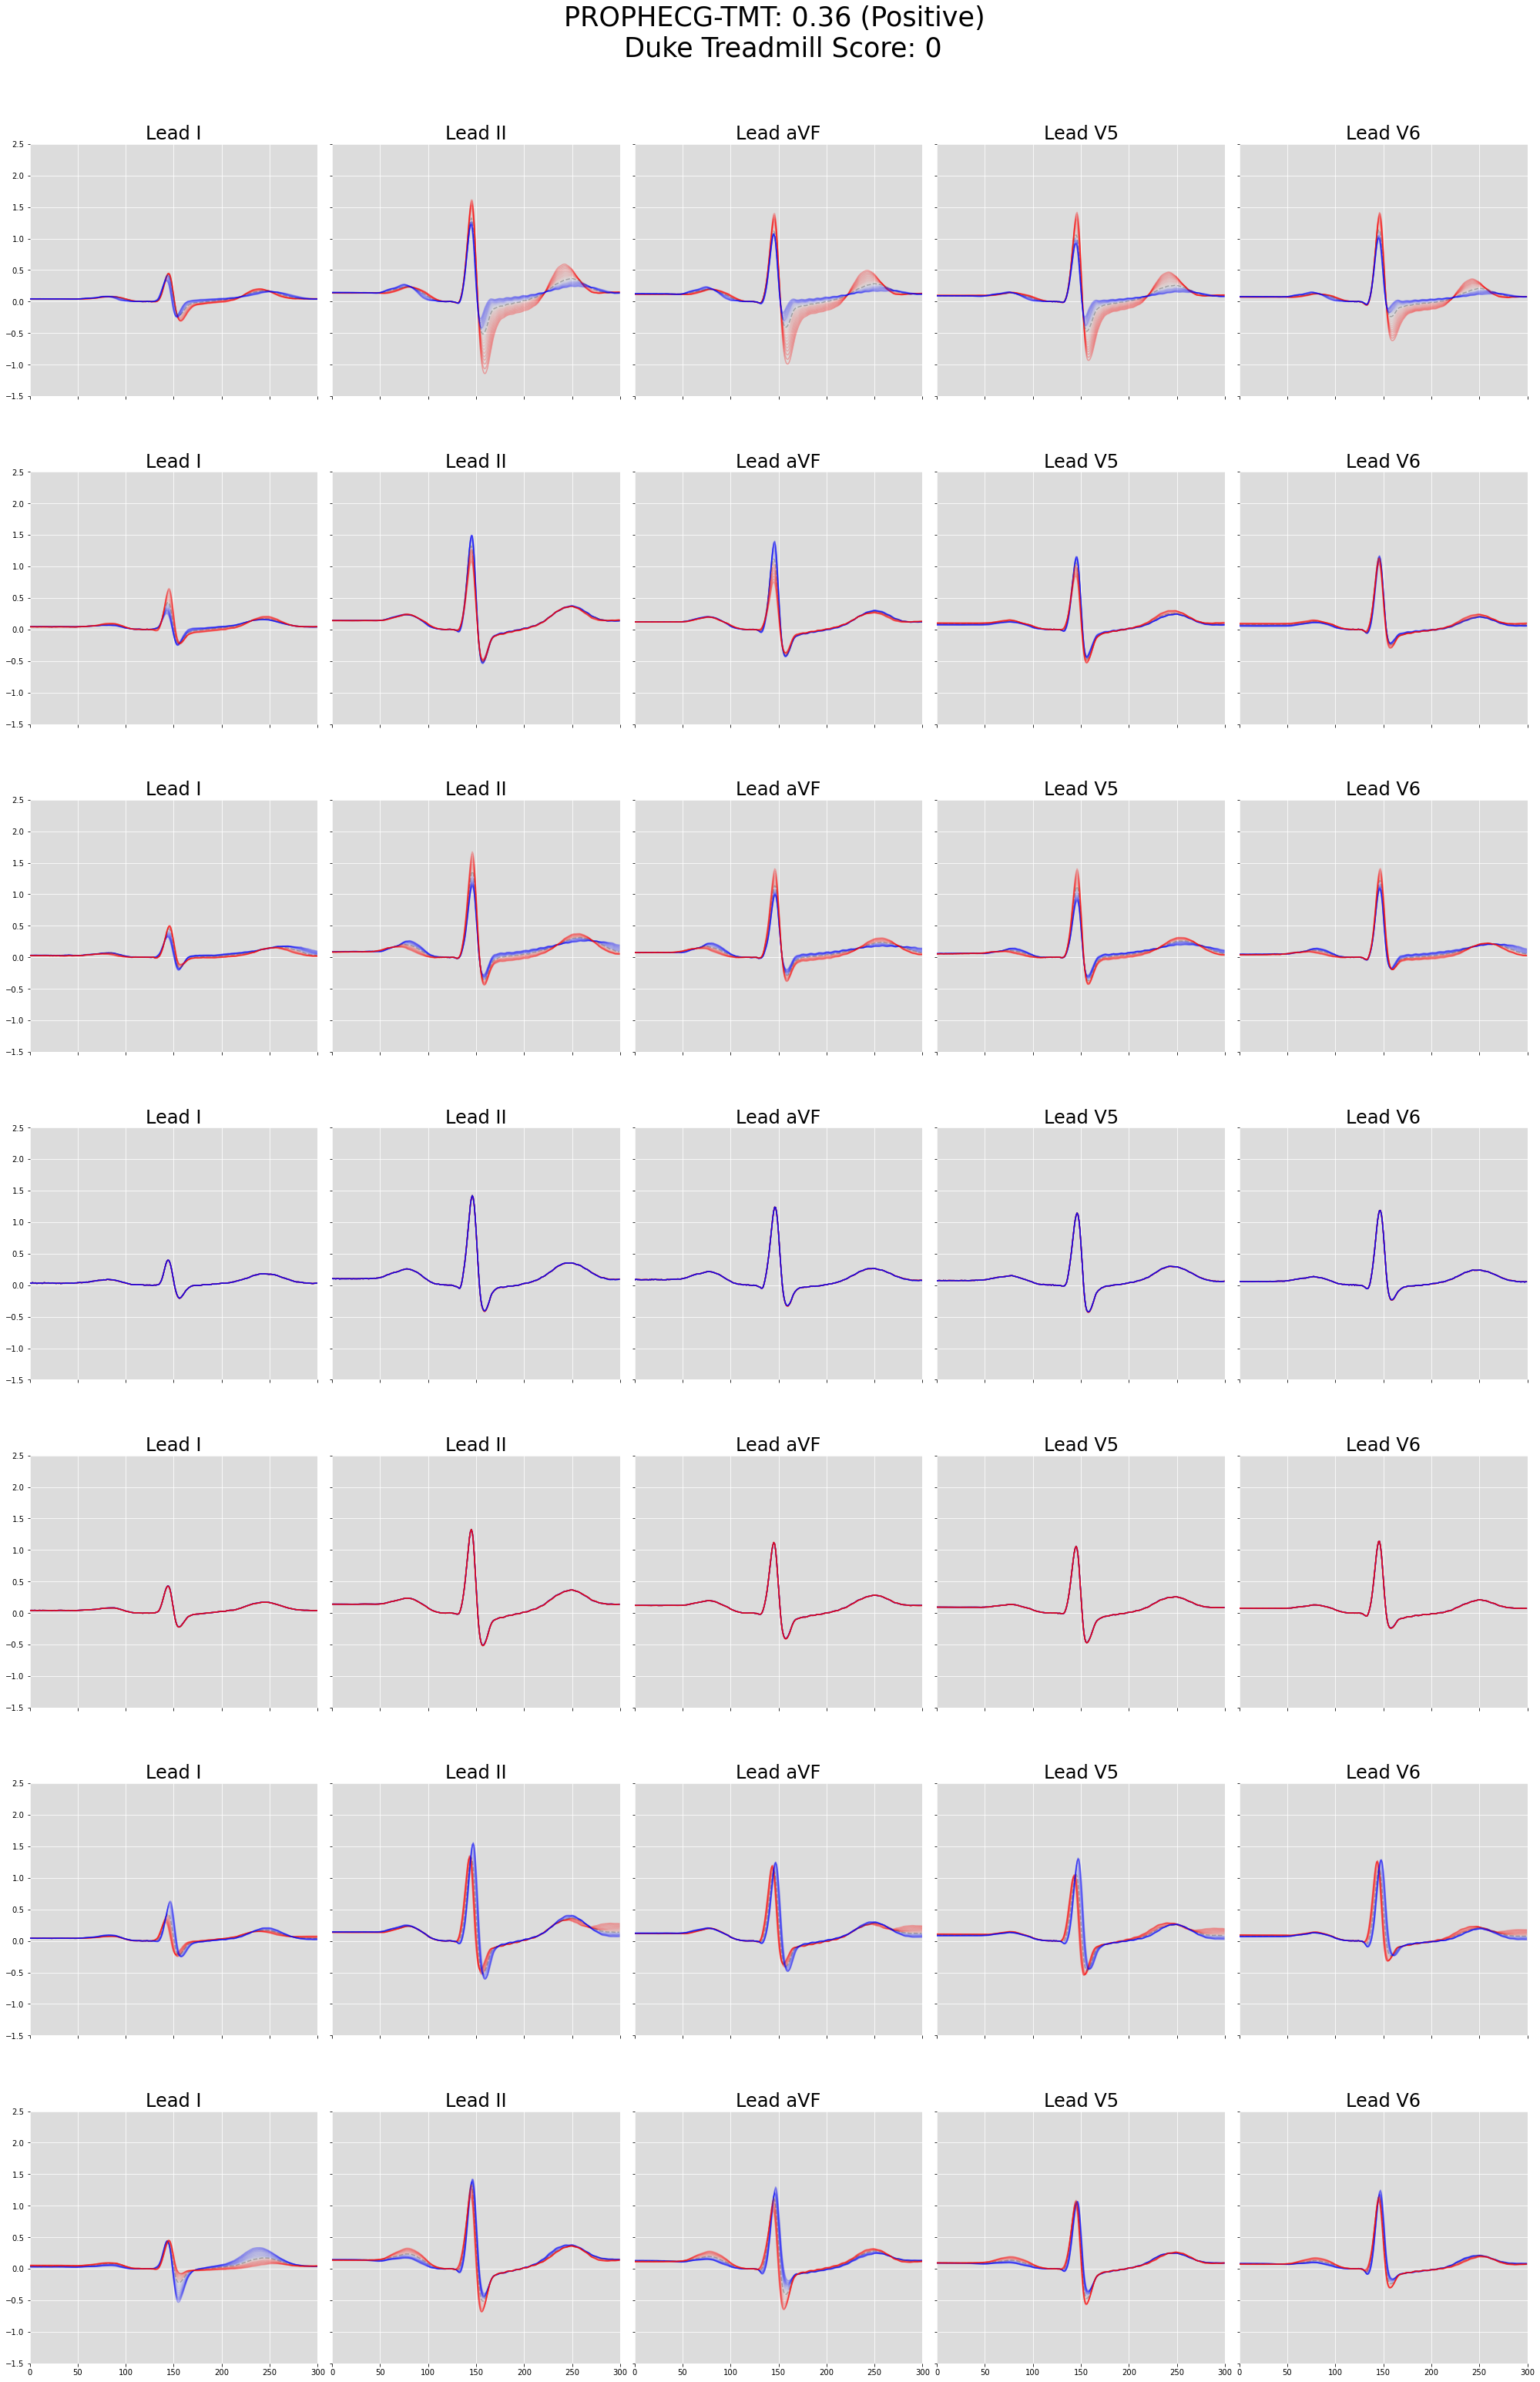

In [29]:
row = file_list.loc[608]

lead_name = ['I', 'II', 'aVF', 'V5', 'V6']
lead_indices = [0, 1, 5, 10, 11]

plot_titles = [
    '2m~4m Recovery Latent 26', 
    '2m~4m Recovery Latent 18', 
    'STAGE1 Latent 1', 
    'STAGE4 Latent 25',
    '2m~4m Recovery Latent 2', 
    '0m~2m Recovery Latent 26',
    '0m~2m Recovery Latent 12'
]
latent_indices = [25, 17, 0, 24, 1, 25, 11]
vae_stages = [vae_stageR, vae_stageR, vae_stage1, vae_stage4, vae_stageR, vae_stageR, vae_stageR]
color_logic = [
    lambda a: 'red' if a < 0 else 'blue' if a > 0 else 'dimgrey',
    lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey',
    lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey',
    lambda a: 'red' if a < 0 else 'blue' if a > 0 else 'dimgrey',
    lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey',
    lambda a: 'red' if a < 0 else 'blue' if a > 0 else 'dimgrey',
    lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey'
]
alpha_logic = [
    lambda a: 0.5 if a == 0 else 0.1 * abs(a),
    lambda a: 0.5 if a == 0 else 0.1 * abs(a),
    lambda a: 0.5 if a == 0 else 0.1 * abs(a),
    lambda a: 0.5 if a == 0 else 0.1 * abs(a),
    lambda a: 0.5 if a == 0 else 0.1 * abs(a),
    lambda a: 0.5 if a == 0 else 0.1 * abs(a),
    lambda a: 0.5 if a == 0 else 0.1 * abs(a)
]

fig, axs = plt.subplots(7, 5, figsize=(30, 50), sharey=True, sharex=True)
fig.subplots_adjust(hspace=0.3, wspace=0.05, top=0.85, bottom=0.05, left=0.05, right=0.95)

# text_info = f'PROPHECG-TMT: {round(row.Prob_Revascularization,2)} ({"Negative" if row.Prob_Revascularization <= 0.068 else "Positive"}) \nBaseline Systolic BP: {row.s1_baseline_sys}  STAGE 1 Systolic BP: {row.s1_sys}  STAGE 2 Systolic BP: {row.s2_sys}  Early Recovery Systolic BP: {row.sr1_sys}'
text_info = f'PROPHECG-TMT: {round(row.Prob_Revascularization,2)} ({"Negative" if row.Prob_Revascularization <= 0.068 else "Positive"}) \n Duke Treadmill Score: {row.duke_score}'

fig.text(0.5, 0.90, text_info, ha='center', fontsize=35, va='top')

for idx, (latent_idx, vae_stage, title, color_func, alpha_func) in enumerate(zip(latent_indices, vae_stages, plot_titles, color_logic, alpha_logic)):
    for i, a in enumerate(np.arange(-3, 3, 0.25)):
        tensor = torch.zeros(1, 32)
        tensor[0, latent_idx] = a
        reconstruction_mean, reconstruction_std = vae_stage.decoder(tensor.float())
        digit = reconstruction_mean.detach().cpu()
        for k, j in enumerate(lead_indices):
            line_style = '--' if a == 0 else '-'
            axs[idx, k].plot(digit[0][j], color=color_func(a), alpha=alpha_func(a), linestyle=line_style)
            axs[idx, k].set_title(f'Lead {lead_name[k]}', fontsize=24)
            axs[idx, k].grid(color='white')

#     tensor = torch.zeros(1, 32)
#     tensor[0, latent_idx] = value
#     reconstruction_mean, reconstruction_std = vae_stage.decoder(tensor.float())
#     digit = reconstruction_mean.detach().cpu()
#     for p, j in enumerate(lead_indices):
#         axs[idx, p].plot(digit[0][j], color='black', alpha=1, linewidth=1.2)
#         axs[idx, p].set_title(f'Lead {lead_name[p]}', fontsize=24)
#         axs[idx, p].grid(color='white')

#     axs[idx, 0].set_ylabel(title, fontsize=30, rotation=90, labelpad=30)

for ax in axs.flat:
    ax.set_facecolor('gainsboro')
    # Remove plot borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.xlim(0, 300)
plt.ylim(-1.5, 2.5)

In [82]:
raw_data = pd.read_csv("/home/ubuntu/djboo/FactorECG/TMT/Datasets/Downstream/Revascularization/240506_downstream_predict_with_r3bp.csv")
results = pd.read_csv("/home/ubuntu/djboo/FactorECG/TMT/Datasets/Downstream/Revascularization/240705_downstream_test_whole_relative.csv")

In [31]:
# 240	10222300
test_df=pd.read_csv('/home/ubuntu/djboo/FactorECG/TMT/Datasets/Downstream/Revascularization/240503_downstream_test_whole.csv')
test_df[test_df["PseudoID"]==10650049]

,Unnamed: 0,PseudoID,AcqDate,TestID,shape,stage,SampleBase,Gain,length,CAD,Revascularization,TMT_fname
31730,31730,10650049,20231027,10650049_20231027_048,"(333, 12)",SITTING,500,5,333,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML
31731,31731,10650049,20231027,10650049_20231027_049,"(343, 12)",STAGE 1,500,5,343,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML
31732,31732,10650049,20231027,10650049_20231027_117,"(344, 12)",STAGE 1,500,5,344,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML
31733,31733,10650049,20231027,10650049_20231027_147,"(329, 12)",STAGE 1,500,5,329,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML
31734,31734,10650049,20231027,10650049_20231027_217,"(341, 12)",STAGE 1,500,5,341,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML
31735,31735,10650049,20231027,10650049_20231027_247,"(325, 12)",STAGE 2,500,5,325,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML
31736,31736,10650049,20231027,10650049_20231027_317,"(331, 12)",STAGE 2,500,5,331,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML
31737,31737,10650049,20231027,10650049_20231027_337,"(321, 12)",STAGE 2,500,5,321,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML
31738,31738,10650049,20231027,10650049_20231027_347,"(322, 12)",STAGE 2,500,5,322,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML
31739,31739,10650049,20231027,10650049_20231027_417,"(313, 12)",STAGE 3,500,5,313,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML


In [53]:
test_df['Time']=test_df["TestID"].str.split('_').str[2].astype('int')
test_df[test_df["PseudoID"]==10650049].groupby(["stage"]).apply(lambda x: x.loc[x['Time'].idxmax()])

,Unnamed: 0,PseudoID,AcqDate,TestID,shape,stage,SampleBase,Gain,length,CAD,Revascularization,TMT_fname,Time
stage,,,,,,,,,,,,,
#1,31745,10650049,20231027,10650049_20231027_647,"(306, 12)",#1,500,5,306,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML,647
#2,31748,10650049,20231027,10650049_20231027_817,"(288, 12)",#2,500,5,288,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML,817
#3,31768,10650049,20231027,10650049_20231027_1447,"(321, 12)",#3,500,5,321,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML,1447
SITTING,31730,10650049,20231027,10650049_20231027_048,"(333, 12)",SITTING,500,5,333,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML,48
STAGE 1,31734,10650049,20231027,10650049_20231027_217,"(341, 12)",STAGE 1,500,5,341,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML,217
STAGE 2,31738,10650049,20231027,10650049_20231027_347,"(322, 12)",STAGE 2,500,5,322,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML,347
STAGE 3,31742,10650049,20231027,10650049_20231027_547,"(313, 12)",STAGE 3,500,5,313,1,1,case2/10650049#Yu#2023_10_27#15_51_09#.XML,547


In [54]:
ecg_mid1 = pd.read_csv("/home/ubuntu/dr-you-ecg-20220420_mount/Users/dachungBoo/DachungBoo_TMT/240116_TMT_medianWaveform/10650049_20231027_647.csv")
ecg_mid2 = pd.read_csv("/home/ubuntu/dr-you-ecg-20220420_mount/Users/dachungBoo/DachungBoo_TMT/240116_TMT_medianWaveform/10650049_20231027_817.csv")

In [93]:
results = pd.read_csv("/home/ubuntu/djboo/FactorECG/TMT/Datasets/Downstream/Revascularization/240705_downstream_test_whole_relative.csv")
sample1 = results[results["PseudoID"]==10650049]
sample1

,Unnamed: 0,PseudoID,AcqDate,CAD,Revascularization,s1_sys,s1_dias,s1_baseline_sys,s1_baseline_dias,s1_relative1_sys,...,sr2_latent_18,sr2_latent_19,sr2_latent_21,sr2_latent_23,sr2_latent_24,sr2_latent_25,sr2_latent_26,sr2_latent_28,sr2_latent_29,sr2_latent_32
794,794,10650049,20231027,1,1,107.0,83.0,132.0,96.0,-2.072353,...,0.394716,0.325884,-0.923856,-0.535096,0.151353,1.445431,-0.512093,-0.104196,0.700138,0.389627


In [100]:
file_list=pd.read_excel("/home/ubuntu/djboo/FactorECG/240526_test_set_final.xlsx")
sample2 = file_list[file_list["PseudoID"]==10650049][["PseudoID", "AcqDate", "Prob_Revascularization", "duke_score"]]
sample2["AcqDate"]=sample2["AcqDate"].astype("str").str.replace('-', '').astype("int")
sample2

,PseudoID,AcqDate,Prob_Revascularization,duke_score
776,10650049,20231027,0.083589,3


In [126]:
sample = pd.merge(sample1, sample2, left_on = ["PseudoID", "AcqDate"],  right_on = ["PseudoID", "AcqDate"], how="left")
row = 0

In [135]:
def plot_combined_reconstructions(values):
    lead_name = ['I', 'II', 'aVF', 'V5', 'V6']
    lead_indices = [0, 1, 5, 10, 11]
    plot_titles = [
        'Mid Recovery Latent 26', 'Mid Recovery Latent 18', 'STAGE2 Latent 1',
        'STAGE4 Latent 25', 'Mid Recovery Latent 2', 'Early Recovery Latent 26',
        'Mid Recovery Latent 12'
    ]
    values_list = [
    values["sr2_latent_26"], values["sr2_latent_18"], values["s2_latent_1"],
    values["s4_latent_25"], values["sr2_latent_2"], values["sr1_latent_26"],
    values["sr1_latent_12"]]
    latent_indices = [25, 17, 0, 24, 1, 25, 11]
    vae_stages = [vae_stageR, vae_stageR, vae_stage2, vae_stage4, vae_stageR, vae_stageR, vae_stageR]
    color_logic = [
        lambda a: 'red' if a < 0 else 'blue' if a > 0 else 'dimgrey',
        lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey',
        lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey',
        lambda a: 'red' if a < 0 else 'blue' if a > 0 else 'dimgrey',
        lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey',
        lambda a: 'red' if a < 0 else 'blue' if a > 0 else 'dimgrey',
        lambda a: 'red' if a > 0 else 'blue' if a < 0 else 'dimgrey'
    ]
    alpha_logic = [
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a),
        lambda a: 0.5 if a == 0 else 0.1 * abs(a)
    ]

    fig, axs = plt.subplots(7, 5, figsize=(30, 50), sharey=True, sharex=True)
    fig.subplots_adjust(hspace=0.3, wspace=0.05, top=0.85, bottom=0.05, left=0.05, right=0.95)

    text_info = f'PROPHECG-TMT: {round(values.Prob_Revascularization,2)} ({"Negative" if values.Prob_Revascularization <= 0.068 else "Positive"}) \nDuke Treadmill Score: {values.duke_score} \nBaseline Systolic BP: {values.s1_baseline_sys}  STAGE 1 Systolic BP: {values.s1_sys}  STAGE 2 Systolic BP: {values.s2_sys}  Early Recovery Systolic BP: {values.sr1_sys}'
    fig.text(0.5, 0.90, text_info, ha='center', fontsize=35, va='top')

    for idx, (value, latent_idx, vae_stage, title, color_func, alpha_func) in enumerate(zip(values_list, latent_indices, vae_stages, plot_titles, color_logic, alpha_logic)):
        for i, a in enumerate(np.arange(-3, 3, 0.25)):
            tensor = torch.zeros(1, 32)
            tensor[0, latent_idx] = a
            reconstruction_mean, reconstruction_std = vae_stage.decoder(tensor.float())
            digit = reconstruction_mean.detach().cpu()
            for k, j in enumerate(lead_indices):
                line_style = '--' if a == 0 else '-'
                axs[idx, k].plot(digit[0][j], color=color_func(a), alpha=alpha_func(a), linestyle=line_style)
                axs[idx, k].set_title(f'Lead {lead_name[k]}', fontsize=24)
                axs[idx, k].grid(color='gray')

        tensor = torch.zeros(1, 32)
        tensor[0, latent_idx] = value
        reconstruction_mean, reconstruction_std = vae_stage.decoder(tensor.float())
        digit = reconstruction_mean.detach().cpu()
        for p, j in enumerate(lead_indices):
            axs[idx, p].plot(digit[0][j], color='black', alpha=1, linewidth=1.2)
            axs[idx, p].set_title(f'Lead {lead_name[p]}', fontsize=24)
            axs[idx, p].grid(color='white')
            
        axs[idx, 0].set_ylabel(title, fontsize=30, rotation=90, labelpad=30)

    for ax in axs.flat:
        ax.set_facecolor('gainsboro')
        # Remove plot borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

    plt.xlim(0, 300)
    plt.ylim(-1.5, 2.5)
    
    for column in lead_name:
        plt.figure()  # 새로운 플롯 창 생성
        plt.plot(ecg_mid2[column], label=column)
        plt.title(f"Plot for column: {column}")
        plt.xlabel("Index")
        plt.ylabel("Values")
        plt.legend()
        plt.ylim(-250, 300)
        plt.show()

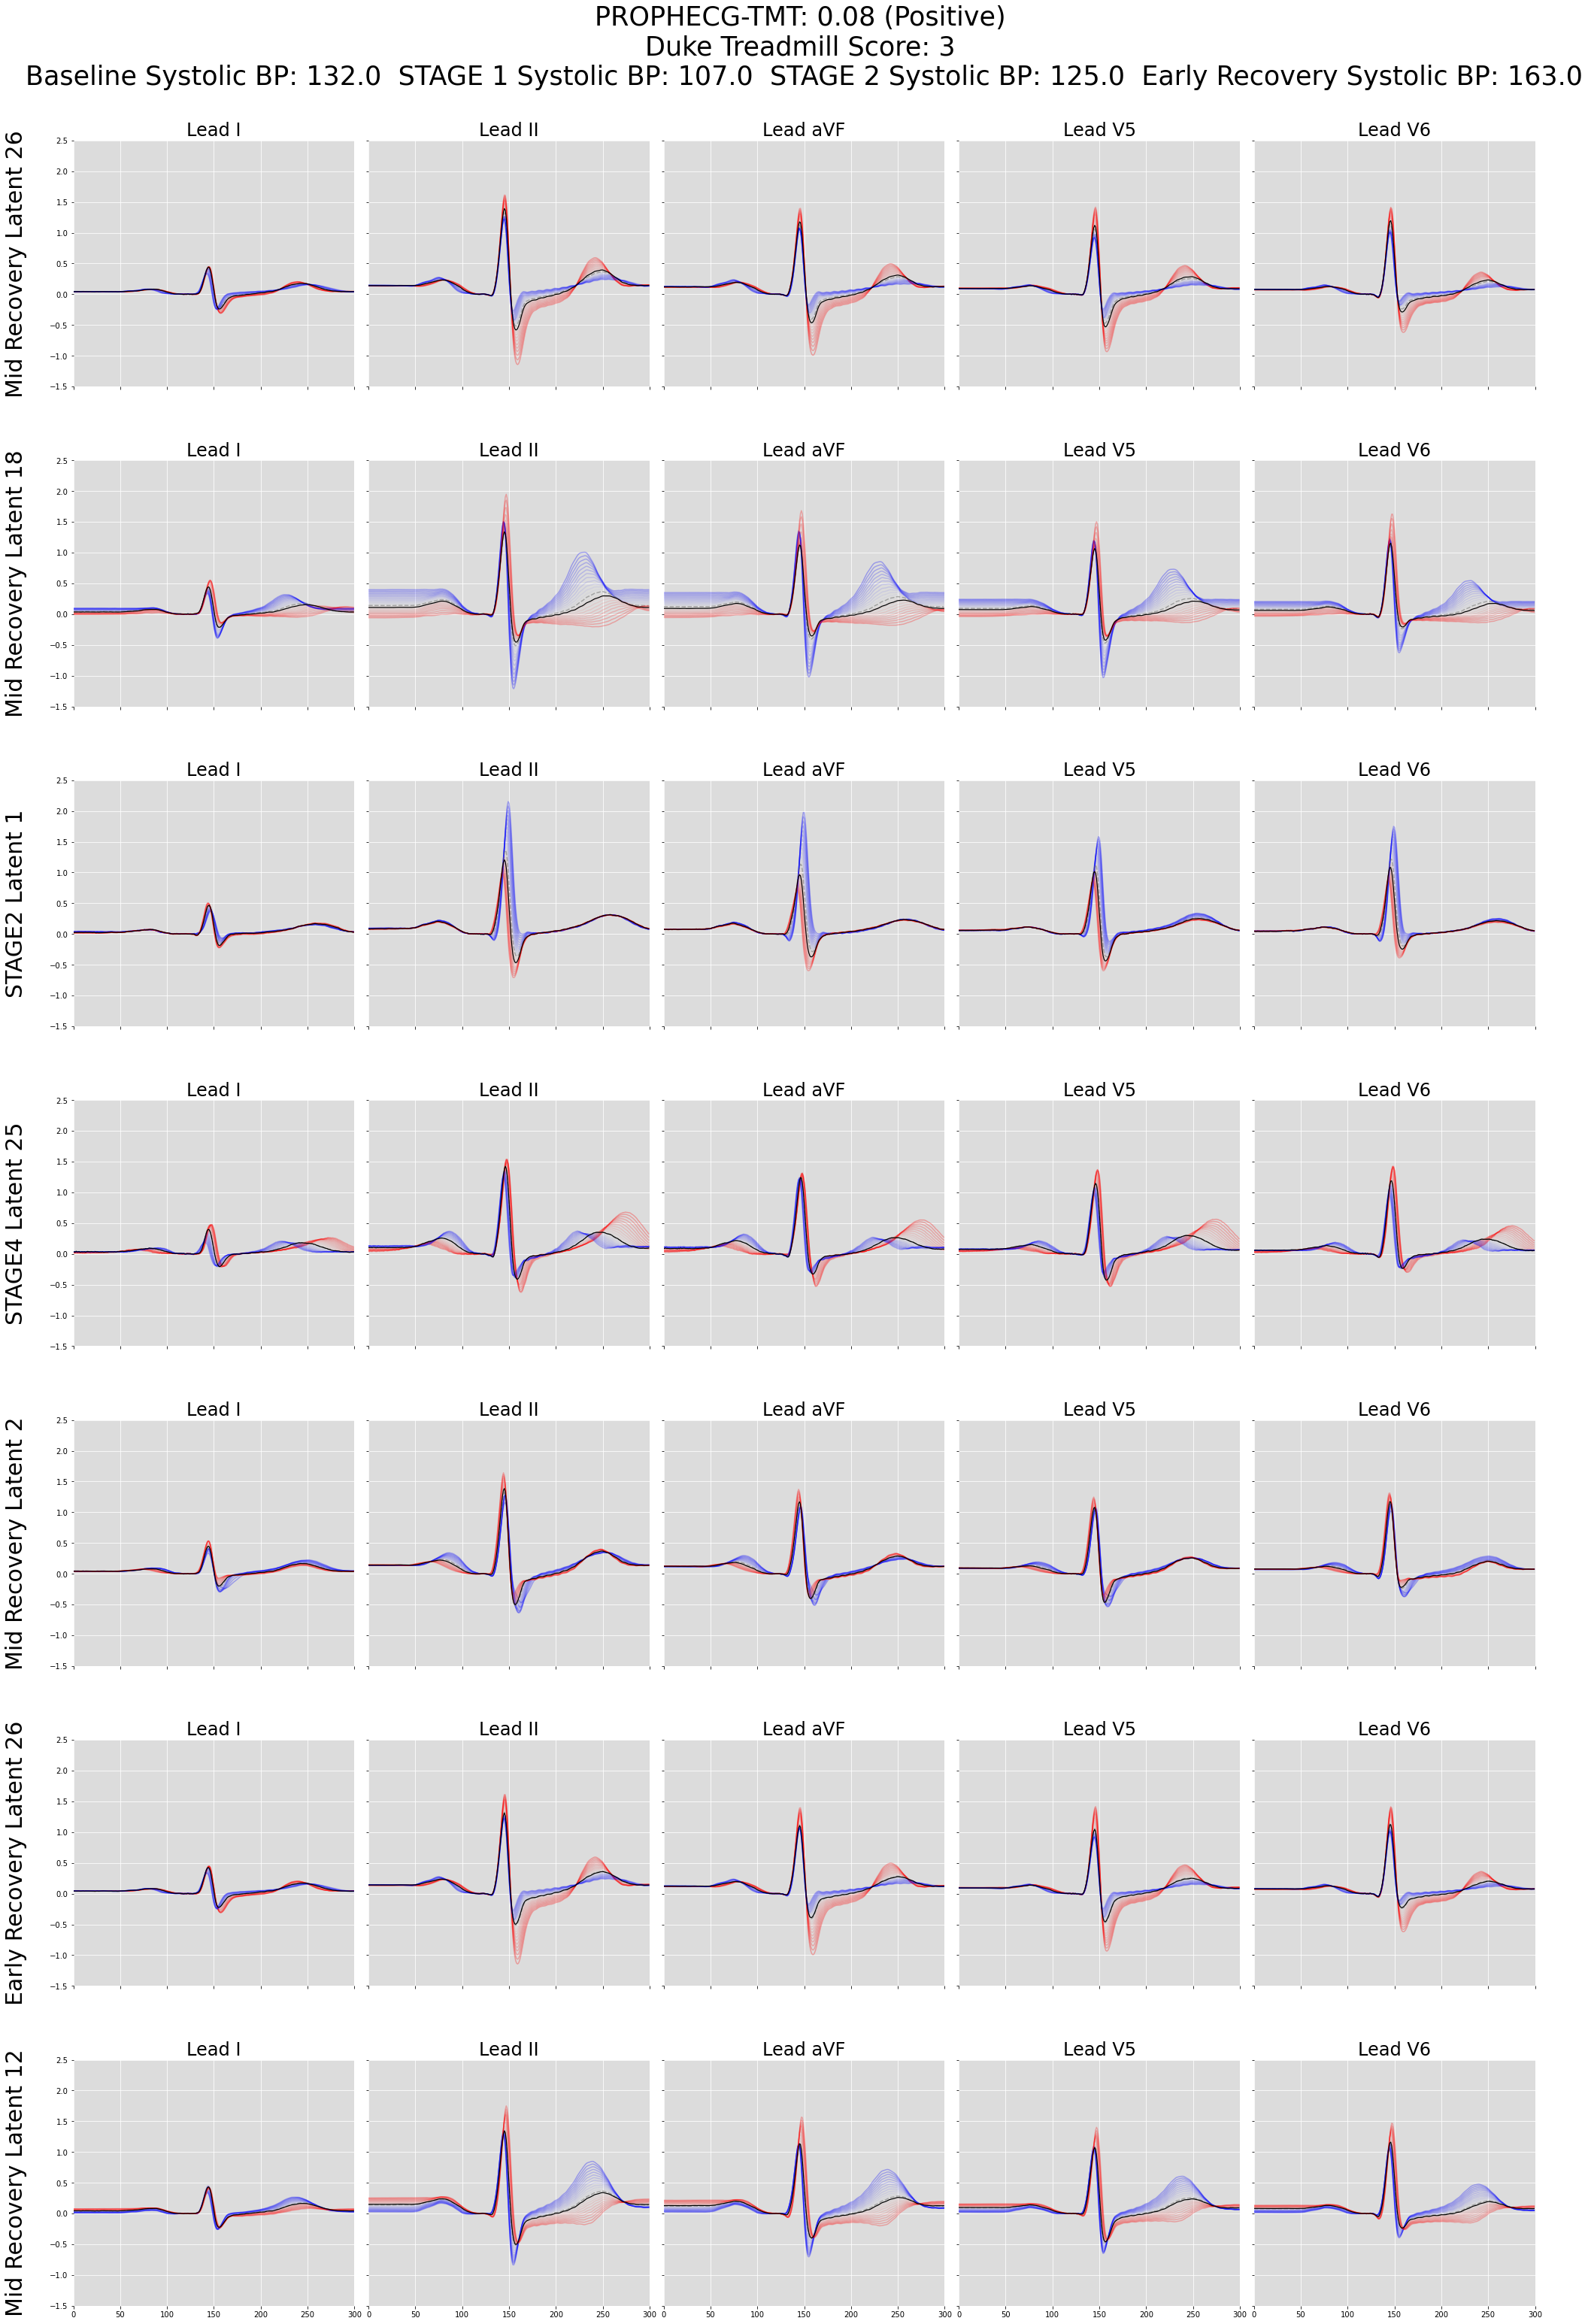

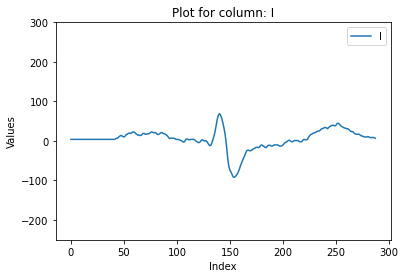

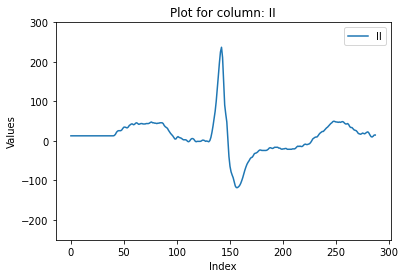

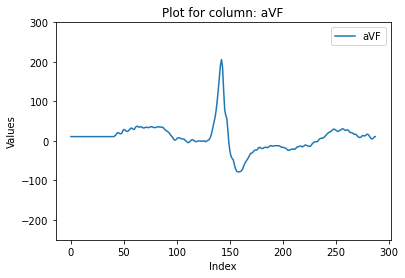

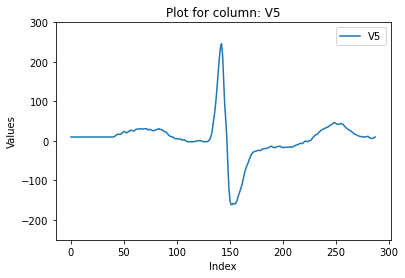

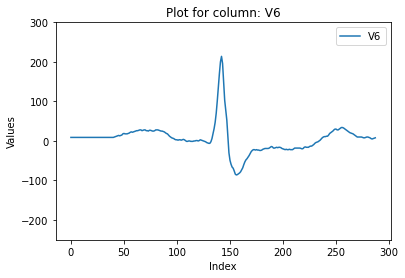

In [136]:
plot_combined_reconstructions(row)

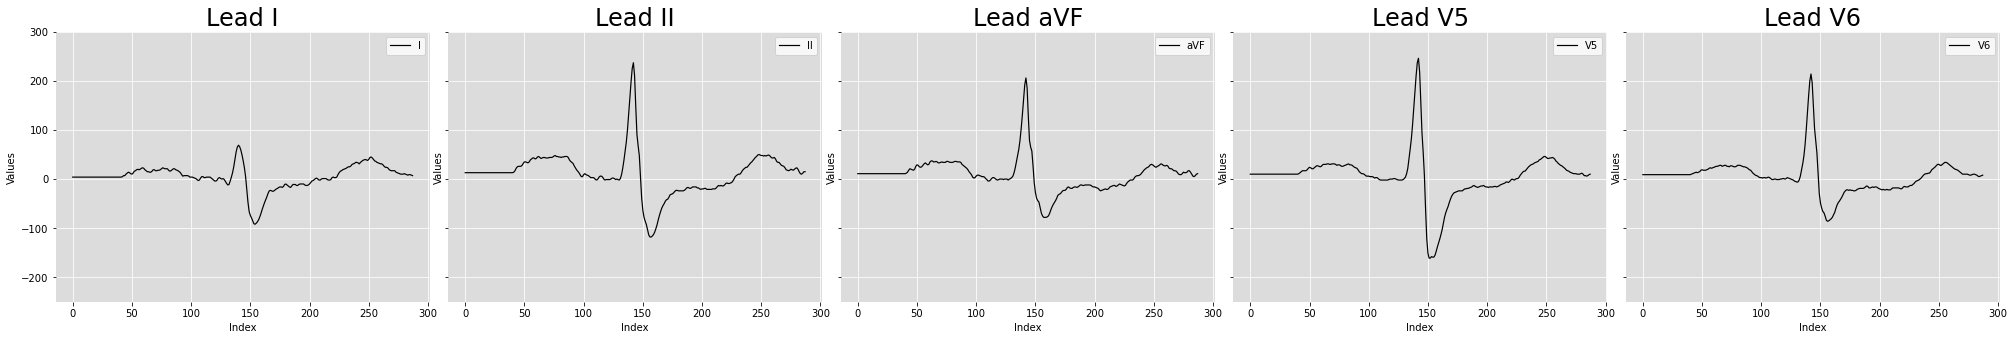

In [140]:
fig, axs = plt.subplots(1, len(lead_name), figsize=(30, 5), sharey=True, sharex=True)
fig.subplots_adjust(hspace=0.3, wspace=0.05, top=0.85, bottom=0.1, left=0.05, right=0.95)

for idx, (ax, column) in enumerate(zip(axs, lead_name)):
    # 기본 데이터 플로팅
    ax.plot(ecg_mid2[column], label=column, color='black', alpha=1, linewidth=1.2)
    ax.set_title(f"Lead {column}", fontsize=24)
    ax.set_xlabel("Index")
    ax.set_ylabel("Values")
    ax.legend()
    ax.set_ylim(-250, 300)
    
    # 스타일 및 레이아웃 조정
    ax.set_facecolor('gainsboro')  # 배경색
    ax.grid(color='white')        # 흰색 그리드
    ax.spines['top'].set_visible(False)  # 테두리 제거
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.show()